# Objetivo

## English

The goal of this notebook is to introduce the first Gradient Boosting model into the World Cup Predictor pipeline.

This notebook uses the selected feature dataset from V03:

`data/processed/match_vector_v03.csv`

The main objectives are:

- Understand the conceptual difference between Random Forest and Gradient Boosting.
- Train a first baseline XGBoost model.
- Compare XGBoost against previous models.
- Analyze XGBoost feature importance.
- Decide whether XGBoost is a promising direction for future optimization.

## Español

El objetivo de esta *notebook* es incorporar el primer modelo de Gradient Boosting al flujo de trabajo del predictor de la Copa del Mundo.

Esta *notebook* utiliza el conjunto de datos con las características seleccionadas en la versión V03:

`data/processed/match_vector_v03.csv`

Los objetivos principales son:

- Comprender la diferencia conceptual entre Random Forest y Gradient Boosting.
- Entrenar un primer modelo base de XGBoost.
- Comparar XGBoost con los modelos anteriores.
- Analizar la importancia de las características en XGBoost.
- Determinar si XGBoost representa una vía prometedora para futuras optimizaciones.

# Configuración

## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Vector Load

In [2]:
df = pd.read_csv("../data/processed/match_vector_v03.csv")

df.head()

,match_id,match_date,kick_off,year,home_team,away_team,home_score,away_score,competition_stage,home_Ball Receipt*,...,sum_Interception,sum_Miscontrol,sum_Offside,sum_Own Goal Against,sum_Pass,sum_Player Off,sum_Player On,sum_Pressure,sum_Shield,sum_Shot
0,7525,2018-06-14,15:00:00.000,2018,Russia,Saudi Arabia,5,0,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7578,2018-06-15,12:00:00.000,2018,Egypt,Uruguay,0,1,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7577,2018-06-15,15:00:00.000,2018,Morocco,Iran,0,1,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7576,2018-06-15,18:00:00.000,2018,Portugal,Spain,3,3,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7530,2018-06-16,10:00:00.000,2018,France,Australia,2,1,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.shape

(128, 134)

In [4]:
df.columns.tolist()

['match_id',
 'match_date',
 'kick_off',
 'year',
 'home_team',
 'away_team',
 'home_score',
 'away_score',
 'competition_stage',
 'home_Ball Receipt*',
 'home_Ball Recovery',
 'home_Block',
 'home_Carry',
 'home_Clearance',
 'home_Dispossessed',
 'home_Dribble',
 'home_Dribbled Past',
 'home_Duel',
 'home_Error',
 'home_Foul Committed',
 'home_Foul Won',
 'home_Goal Keeper',
 'home_Interception',
 'home_Miscontrol',
 'home_Own Goal Against',
 'home_Pass',
 'home_Player Off',
 'home_Player On',
 'home_Pressure',
 'home_Shot',
 'home_Offside',
 'home_Shield',
 'home_Bad Behaviour',
 'home_50/50',
 'away_Ball Receipt*',
 'away_Ball Recovery',
 'away_Block',
 'away_Carry',
 'away_Clearance',
 'away_Dispossessed',
 'away_Dribble',
 'away_Dribbled Past',
 'away_Duel',
 'away_Error',
 'away_Foul Committed',
 'away_Foul Won',
 'away_Goal Keeper',
 'away_Interception',
 'away_Miscontrol',
 'away_Own Goal Against',
 'away_Pass',
 'away_Player Off',
 'away_Player On',
 'away_Pressure',
 'away_Sh

In [5]:
non_feature_cols = [
    "match_id",
    "match_date",
    "kick_off",
    "year",
    "competition_stage",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "target"
]

## Train - Test Split Function

In [6]:
X = df.drop(columns=non_feature_cols)
y = df["target"]

X.shape, y.shape

((128, 124), (128,))

In [7]:
def prepare_train_test_data(
    df,
    target_col="target",
    train_year=2018,
    test_year=2022,
    drop_cols=None,
):
    """
    Prepare train and test datasets using World Cup editions.

    Parameters
    ----------
    df : pandas.DataFrame
        Match-level dataset.
    target_col : str
        Target column.
    train_year : int
        Year used for training.
    test_year : int
        Year used for testing.
    drop_cols : list, optional
        Additional columns to exclude from the feature matrix.

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    if drop_cols is None:
        drop_cols = [
            "match_id",
            "match_date",
            "kick_off",
            "year",
            "competition_stage",
            "home_team",
            "away_team",
            "home_score",
            "away_score",
            target_col,
        ]

    X = df.drop(columns=drop_cols)
    y = df[target_col]

    train_mask = df["year"] == train_year
    test_mask = df["year"] == test_year

    X_train = X.loc[train_mask]
    X_test = X.loc[test_mask]

    y_train = y.loc[train_mask]
    y_test = y.loc[test_mask]

    return X_train, X_test, y_train, y_test



In [8]:
X_train, X_test, y_train, y_test = prepare_train_test_data(df)

print(X_train.shape)
print(X_test.shape)

(64, 124)
(64, 124)


## Evaluate Model Function V2

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a classification model.

    Parameters
    ----------
    model : estimator
        Any sklearn-compatible classification model.
    X_train, X_test : pandas.DataFrame
        Training and testing feature matrices.
    y_train, y_test : pandas.Series
        Training and testing targets.

    Returns
    -------
    dict
        Dictionary containing accuracy, predictions,
        classification report, and confusion matrix.
    """

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "predictions": y_pred,
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

    return results



# Evaluación de Modelos

In [10]:
comparison_results = []

## Modelos

### Dummy

In [11]:
dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)

dummy_results = evaluate_model(
    dummy_model,
    X_train,
    X_test,
    y_train,
    y_test
)

comparison_results.append({
    "model": "Dummy Classifier",
    "accuracy": dummy_results["accuracy"]
})

dummy_results["accuracy"]

c:\Users\Guido\Documents\Gui Archives\Coding\Mundial 2026\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guido\Documents\Gui Archives\Coding\Mundial 2026\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guido\Documents\Gui Archives\Coding\Mundial 2026\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

0.453125

### Logistic Regression

In [12]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_results = evaluate_model(
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test
)

comparison_results.append({
    "model": "Logistic Regression",
    "accuracy": logistic_results["accuracy"]
})

logistic_results["accuracy"]

c:\Users\Guido\Documents\Gui Archives\Coding\Mundial 2026\world-cup-predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.34375

### Logistic Scaled

In [13]:
logistic_scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_scaled_results = evaluate_model(
    logistic_scaled_model,
    X_train,
    X_test,
    y_train,
    y_test
)

comparison_results.append({
    "model": "Logistic Regression + StandardScaler",
    "accuracy": logistic_scaled_results["accuracy"]
})

logistic_scaled_results["accuracy"]


0.34375

### Random Forest

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_results = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

comparison_results.append({
    "model": "Random Forest",
    "accuracy": rf_results["accuracy"]
})

rf_results["accuracy"]

0.515625

### XGBoost

In [15]:
y_train.unique()

array([ 1, -1,  0])

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

label_encoder.classes_

array([-1,  0,  1])

In [17]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train_encoded,
    y_test_encoded
)

comparison_results.append({
    "model": "XGBoost",
    "accuracy": xgb_results["accuracy"]
})

xgb_results["accuracy"]

0.375

In [18]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train_encoded,
    y_test_encoded
)

comparison_results.append({
    "model": "XGBoost (Conservative)",
    "accuracy": xgb_results["accuracy"]
})

xgb_results["accuracy"]

0.40625

Un pequeño ajuste manual mejoró la performance, aunque XGBoost todavía no performa tanto como Random Forest.

A small manual adjustment improved performance, although XGBoost still underperformed Random Forest.

## Resultados

In [19]:
comparison_df = (
    pd.DataFrame(comparison_results)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

comparison_df

,model,accuracy
0,Random Forest,0.515625
1,Dummy Classifier,0.453125
2,XGBoost (Conservative),0.406250
3,XGBoost,0.375000
4,Logistic Regression,0.343750
5,Logistic Regression + StandardScaler,0.343750


# Feature Importance

In [20]:
xgb_feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_feature_importance.head(20)

,feature,importance
96,relative_diff_Pressure,0.035317
1,home_Ball Recovery,0.026036
56,diff_Clearance,0.021530
88,relative_diff_Goal Keeper,0.019049
81,relative_diff_Dispossessed,0.017886
45,away_Shot,0.017122
80,relative_diff_Clearance,0.017028
57,diff_Dispossessed,0.016791
3,home_Carry,0.016529
10,home_Foul Committed,0.015636


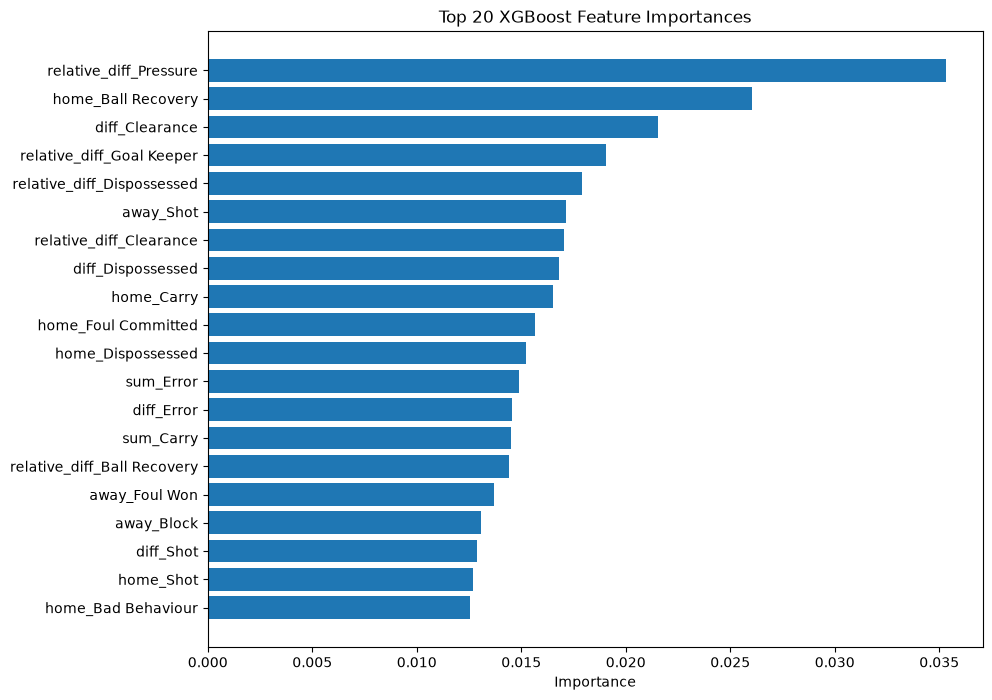

In [21]:
import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10, 8))
plt.barh(
    xgb_feature_importance.head(top_n)["feature"][::-1],
    xgb_feature_importance.head(top_n)["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top 20 XGBoost Feature Importances")
plt.show()

# Model Export

This section exports the final XGBoost model obtained after model evaluation.

The exported artifact contains the trained estimator together with all metadata required to reproduce inference consistently in future notebooks.

### Imports

In [24]:
import joblib
from pathlib import Path

### Build Artifact

In [25]:
artifact = {
    "model": xgb_model,
    "feature_names": list(X_train.columns),
    "target_classes": list(xgb_model.classes_),
    "model_version": "xgboost_v04",
}

### Export Artifact

In [26]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "xgboost_v04.pkl"

joblib.dump(artifact, model_path)

print(model_path)

..\models\xgboost_v04.pkl


### Reload Artifact

In [27]:
loaded_artifact = joblib.load(model_path)

### Validate Artifact

In [28]:
assert loaded_artifact["feature_names"] == list(X_train.columns)

assert list(loaded_artifact["target_classes"]) == list(xgb_model.classes_)

assert (
    loaded_artifact["model"].predict(X_test)
    == xgb_model.predict(X_test)
).all()

assert loaded_artifact["model"].n_features_in_ == X_train.shape[1]

print("Artifact successfully validated.")
print(f"Model version: {loaded_artifact['model_version']}")
print(f"Number of features: {len(loaded_artifact['feature_names'])}")
print(f"Target classes: {loaded_artifact['target_classes']}")

Artifact successfully validated.
Model version: xgboost_v04
Number of features: 124
Target classes: [np.int64(0), np.int64(1), np.int64(2)]


# Conclusión

## English

- The first Gradient Boosting model was successfully introduced into the project.
- XGBoost was evaluated alongside all previously tested models.
- The baseline XGBoost model did not outperform the Random Forest classifier.
- A small manual hyperparameter adjustment improved performance, although it remained below the Random Forest baseline.
- The limited number of training samples (64 matches) is likely restricting XGBoost's full potential.
- Feature importance rankings differed considerably from those obtained with Random Forest, indicating that feature relevance is model-dependent.
- XGBoost remains a promising algorithm and will be the focus of a systematic hyperparameter optimization in the next notebook.

In [22]:
observations = {
    "Dummy Classifier": "Baseline model",
    "Logistic Regression": "Linear baseline",
    "Logistic Regression + StandardScaler": "Linear baseline with feature scaling",
    "Random Forest": "Best overall performance",
    "XGBoost": "Default configuration",
    "XGBoost (Conservative)": "Improved after manual tuning"
}

comparison_df["observation"] = comparison_df["model"].map(observations)

comparison_df

,model,accuracy,observation
0,Random Forest,0.515625,Best overall performance
1,Dummy Classifier,0.453125,Baseline model
2,XGBoost (Conservative),0.406250,Improved after manual tuning
3,XGBoost,0.375000,Default configuration
4,Logistic Regression,0.343750,Linear baseline
5,Logistic Regression + StandardScaler,0.343750,Linear baseline with feature scaling


## Español

- Se incorporó exitosamente el primer modelo de Gradient Boosting al proyecto.
- XGBoost fue evaluado junto con todos los modelos analizados anteriormente.
- El modelo base de XGBoost no logró superar al clasificador Random Forest.
- Un pequeño ajuste manual de hiperparámetros mejoró el rendimiento, aunque permaneció por debajo del obtenido por Random Forest.
- La limitada cantidad de ejemplos de entrenamiento (64 partidos) probablemente esté restringiendo el potencial completo de XGBoost.
- Las importancias de las variables difirieron considerablemente de las obtenidas con Random Forest, lo que indica que la relevancia de una característica depende del modelo utilizado.
- XGBoost continúa siendo un algoritmo prometedor y será objeto de una optimización sistemática de hiperparámetros en la próxima notebook.

In [23]:
observaciones = {
    "Dummy Classifier": "Modelo base",
    "Logistic Regression": "Modelo lineal",
    "Logistic Regression + StandardScaler": "Modelo lineal con estandarización",
    "Random Forest": "Mejor rendimiento general",
    "XGBoost": "Configuración por defecto",
    "XGBoost (Conservative)": "Mejorado mediante ajuste manual"
}

comparison_df["observación"] = comparison_df["model"].map(observaciones)

comparison_df

,model,accuracy,observation,observación
0,Random Forest,0.515625,Best overall performance,Mejor rendimiento general
1,Dummy Classifier,0.453125,Baseline model,Modelo base
2,XGBoost (Conservative),0.406250,Improved after manual tuning,Mejorado mediante ajuste manual
3,XGBoost,0.375000,Default configuration,Configuración por defecto
4,Logistic Regression,0.343750,Linear baseline,Modelo lineal
5,Logistic Regression + StandardScaler,0.343750,Linear baseline with feature scaling,Modelo lineal con estandarización
